In [122]:
# Importing basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [123]:
# I am writing code in google colab thats why i write this code you can practice on kaggle notebook directly
# https://www.kaggle.com/datasets/rkiattisak/salaly-prediction-for-beginer as well but i prefer to code on google
# colab env becuase its CPU and RAM is very high and efficient then kaggles notebook env

from google.colab import files # Importing file for taking file from file explorer
upload = files.upload()

path = list(upload.keys())[0]

df = pd.read_csv(path)

Saving Salary Data.csv to Salary Data (2).csv




# Exploratory Data Analysis(EDA)

In [124]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [125]:
df.shape

(375, 6)

In [126]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [127]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [128]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [129]:
df.isna().sum() # seeing all null and NaN values

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


<Axes: xlabel='Age', ylabel='Count'>

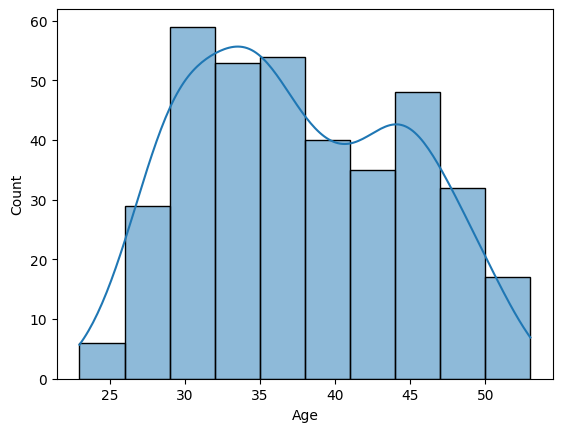

In [130]:
sns.histplot(df['Age'], kde=True)

<Axes: ylabel='Age'>

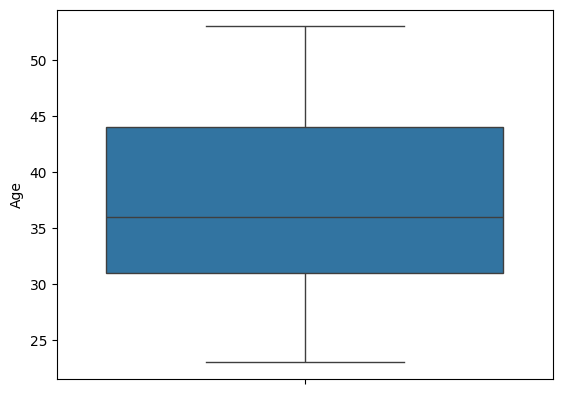

In [131]:
sns.boxplot(df['Age'])

In [132]:
# Importing is_numeric_dtype from pandas.api.types which will check all numeric
# data type eg int32, int64, float32 and float64
from pandas.api.types import is_numeric_dtype

# Creating finding_corr function in which taking qual_col: str as an argument and
# -> None as the return value
def finding_corr(
    qual_col: str,
    target_col: str,
    dataframe: pd.DataFrame) -> tuple[str, str, float | int, float | int] | None:
  try:
    # Creating is_avail container which checks wheter it contains columns or not:
    is_avail = qual_col in dataframe.columns and target_col in dataframe.columns

    # Creating numeric_only container which only contains numeric data types.
    numeric_only = dataframe.select_dtypes(include='number').columns.tolist()

    # Creating a variable which holds the showcasing of numeric_only variable:
    show_numeric = f"AVailable Numeric Columns: {list(numeric_only)}"

    # Checking wheter the column existed or not
    if not is_avail:
      print("Error the column did'nt exists in data frame!")
      print(show_numeric)
      return None

    # Creating is_numeric container which actually check wheter its dtype is numeric or not:
    is_numeric = is_numeric_dtype(dataframe[qual_col]) and is_numeric_dtype(dataframe[target_col])

    if not is_numeric:
      print("Error the column is not numeric!")
      print(show_numeric)
      return None

    # Finding correlation:
    corr = dataframe[qual_col].corr(dataframe[target_col])
    abs_corr = abs(corr)

    # Showing results according to corr value:
    if abs_corr == 1.0:
      print("Perfect Correlation")
    elif abs_corr >= 0.7:
      print("Strong Correlation")
    elif abs_corr >= 0.3:
      print("Moderate Correlation")
    else:
      print("Weak Correlation")

    print(f"Value of corr is {corr}!")
    print(f"Successfully delivered the correlation between '{qual_col}' and '{target_col}'")
    return qual_col, target_col, corr, abs_corr

  except Exception as err:
    # Showing error:
    print(f"Error while seeing correlation occured to due: '{err}'")
    return None

In [133]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [134]:
finding_corr('Age', 'Salary', df) # Finding corr between 'Age' and 'Salary'

Strong Correlation
Value of corr is 0.922335243916644!
Successfully delivered the correlation between 'Age' and 'Salary'


('Age', 'Salary', np.float64(0.922335243916644), np.float64(0.922335243916644))

In [135]:
finding_corr('Age', 'Years of Experience', df) # Finding corr between 'Age' and 'YearsExperience'

Strong Correlation
Value of corr is 0.979128050352751!
Successfully delivered the correlation between 'Age' and 'Years of Experience'


('Age',
 'Years of Experience',
 np.float64(0.979128050352751),
 np.float64(0.979128050352751))

In [136]:
finding_corr('Years of Experience', 'Salary', df) # Finding corr between 'YearsExperience' and 'Salary

Strong Correlation
Value of corr is 0.9303377227618356!
Successfully delivered the correlation between 'Years of Experience' and 'Salary'


('Years of Experience',
 'Salary',
 np.float64(0.9303377227618356),
 np.float64(0.9303377227618356))

In [137]:

df['Gender'].value_counts() # Checking value counts of Male and Female

,count
Gender,
Male,194
Female,179


<Axes: xlabel='count', ylabel='Gender'>

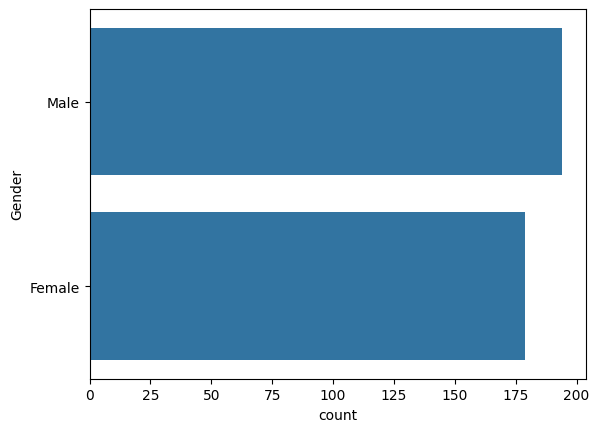

In [138]:
sns.countplot(df['Gender'])

<Axes: xlabel='Gender', ylabel='count'>

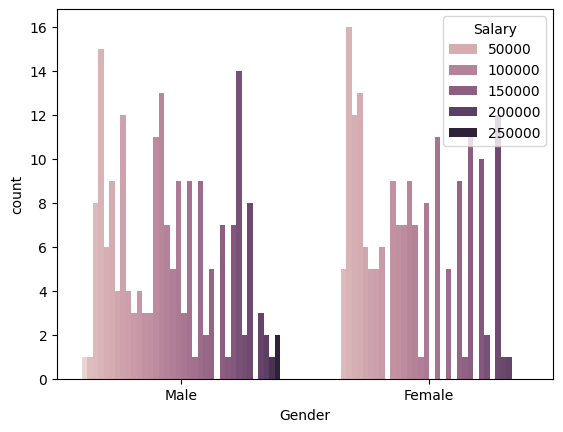

In [139]:
sns.countplot(data=df, x='Gender', hue='Salary')

In [140]:
df.groupby('Gender')['Salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,179.0,97011.173184,45916.141054,35000.0,50000.0,90000.0,140000.0,190000.0
Male,194.0,103867.783505,50182.461438,350.0,60000.0,97500.0,140000.0,250000.0


In [141]:
# Importing chi2_contingency from scipy.stats for testing two categorical variables
from scipy.stats import chi2_contingency
# Importing is_object_dtype and is_categorical_dtype from pandas.api.types
# for checking whether the object is string and categorical
from pandas.api.types import is_object_dtype, is_categorical_dtype

# Creating chi2_testing function which takes cat_col1 and cat_col2
def chi2_testing(
    cat_col1: str,
    cat_col2: str,
    dataframe: pd.DataFrame
    ) -> tuple[int | float, ...] | None:
    try:
        # 1. Check if dataframe is None
        if dataframe is None:
            print("Error: dataframe cannot be None!")
            return

        # 2. Check if dataframe is instance of pd.DataFrame
        if not isinstance(dataframe, pd.DataFrame):
            print("Error: dataframe is not an instance of pd.DataFrame!")
            return

        # 3. Check if the columns exist in dataframe
        column_existance: bool = (
            (cat_col1 in dataframe.columns) and (cat_col2 in dataframe.columns)
        )

        if not column_existance:
            print("Error: the column(s) don't exist in the dataframe!")
            cat_cols: list = dataframe.select_dtypes(include='object').columns.tolist()
            print(f"Available Categorical Columns: {cat_cols}")
            return

        # NOW it's safe to use the columns - all validation passed

        # Get categorical columns for display
        cat_cols: list = dataframe.select_dtypes(include='object').columns.tolist()
        show_cat_col: str = f"Available Categorical Columns: {cat_cols}"

        # Check if columns are categorical/object dtype
        is_legal_dtype = (
            (is_object_dtype(dataframe[cat_col1]) or is_categorical_dtype(dataframe[cat_col1]))
            and
            (is_object_dtype(dataframe[cat_col2]) or is_categorical_dtype(dataframe[cat_col2]))
        )

        if not is_legal_dtype:
            print("Error: the column(s) are not categorical!")
            print(show_cat_col)
            return

        # Check if columns have enough unique values
        if (dataframe[cat_col1].nunique() < 2) or (dataframe[cat_col2].nunique() < 2):
            print("Error: each categorical column must have at least 2 unique values!")
            print(f"'{cat_col1}' has {dataframe[cat_col1].nunique()} unique values")
            print(f"'{cat_col2}' has {dataframe[cat_col2].nunique()} unique values")
            return

        # Creating a contingency table
        contingency_table: pd.DataFrame = pd.crosstab(
            dataframe[cat_col1],
            dataframe[cat_col2]
        )

        # Check if contingency table has valid dimensions
        if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
            print("Error: contingency table must have at least 2 rows and 2 columns!")
            return

        # Performing chi2 test and storing results
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        # Storing result strings with formatting
        show_chi2: str = f"Chi2 Value: {chi2:.4f}"
        show_p_value: str = f"P Value: {p_value:.4f}"
        show_dof: str = f"Degree of Freedom: {dof}"
        show_expected: str = f"Expected Values:\n{expected}"
        show_conclusion: str | None = None

        # Creating alpha value
        alpha = 0.05

        if p_value < alpha:
            show_conclusion = "Reject the null hypothesis (Variables are associated)."
        else:
            show_conclusion = "Fail to reject the null hypothesis (Variables are not associated)."

        # Showing results
        print("\n'CHI 2 RESULTS':\n")
        print(show_chi2)
        print(show_p_value)
        print(show_dof)
        print(show_expected)
        print(show_conclusion)

        return (chi2, p_value, dof, show_conclusion)

    except Exception as err:
        # Showing error
        print(f"Error while performing chi2_test occurs due to: {err}")
        return None

In [142]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [143]:
chi2_testing('Gender', 'Job Title', df)


'CHI 2 RESULTS':

Chi2 Value: 224.5429
P Value: 0.0051
Degree of Freedom: 173
Expected Values:
[[0.47989276 0.47989276 0.95978552 0.95978552 0.47989276 0.47989276
  0.47989276 0.47989276 0.47989276 0.47989276 0.47989276 0.47989276
  0.95978552 0.47989276 0.47989276 0.47989276 0.47989276 0.95978552
  0.47989276 0.47989276 0.47989276 0.47989276 0.47989276 0.47989276
  0.95978552 0.95978552 0.47989276 0.47989276 0.95978552 5.75871314
  5.27882038 0.47989276 0.47989276 0.47989276 0.95978552 0.47989276
  0.47989276 0.47989276 0.47989276 0.95978552 0.95978552 0.47989276
  0.47989276 0.47989276 0.47989276 0.47989276 0.95978552 1.43967828
  0.47989276 3.83914209 3.35924933 0.95978552 0.47989276 0.47989276
  0.47989276 0.47989276 0.47989276 0.47989276 0.47989276 3.35924933
  0.95978552 0.95978552 1.43967828 2.87935657 1.43967828 2.39946381
  2.39946381 0.47989276 1.43967828 1.91957105 2.39946381 0.47989276
  0.47989276 1.91957105 0.47989276 0.47989276 0.95978552 0.47989276
  0.47989276 0.47989

(np.float64(224.54288711985538),
 np.float64(0.005077005902986373),
 173,
 'Reject the null hypothesis (Variables are associated).')

In [144]:

chi2_testing('Gender', 'Education Level', df)


'CHI 2 RESULTS':

Chi2 Value: 0.9051
P Value: 0.6360
Degree of Freedom: 2
Expected Values:
[[107.49597855  47.02949062  24.47453083]
 [116.50402145  50.97050938  26.52546917]]
Fail to reject the null hypothesis (Variables are not associated).


(np.float64(0.9050993133099572),
 np.float64(0.6360044895316009),
 2,
 'Fail to reject the null hypothesis (Variables are not associated).')

In [145]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [146]:
df['Education Level'].value_counts()

,count
Education Level,
Bachelor's,224
Master's,98
PhD,51


<Axes: xlabel='count', ylabel='Education Level'>

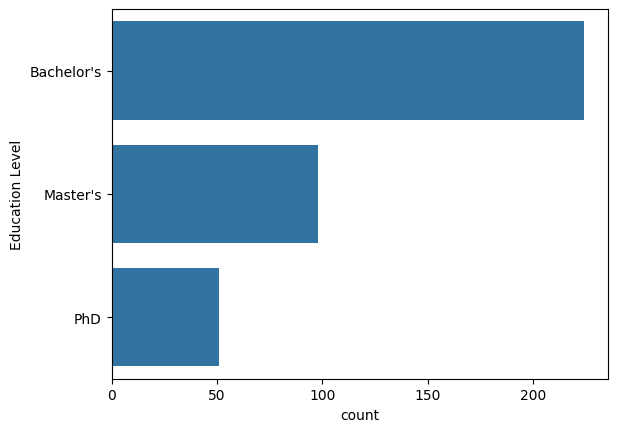

In [147]:
sns.countplot(df['Education Level'])

<Axes: xlabel='Education Level', ylabel='count'>

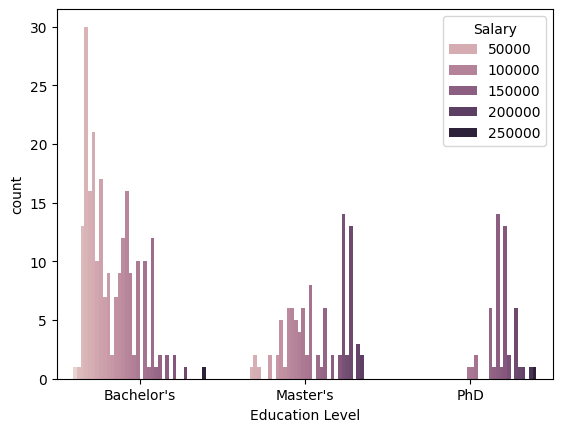

In [148]:
sns.countplot(data=df, x='Education Level', hue='Salary')

In [149]:
chi2_testing('Education Level', 'Job Title', df)


'CHI 2 RESULTS':

Chi2 Value: 594.6375
P Value: 0.0000
Degree of Freedom: 346
Expected Values:
[[0.60053619 0.60053619 1.20107239 1.20107239 0.60053619 0.60053619
  0.60053619 0.60053619 0.60053619 0.60053619 0.60053619 0.60053619
  1.20107239 0.60053619 0.60053619 0.60053619 0.60053619 1.20107239
  0.60053619 0.60053619 0.60053619 0.60053619 0.60053619 0.60053619
  1.20107239 1.20107239 0.60053619 0.60053619 1.20107239 7.20643432
  6.60589812 0.60053619 0.60053619 0.60053619 1.20107239 0.60053619
  0.60053619 0.60053619 0.60053619 1.20107239 1.20107239 0.60053619
  0.60053619 0.60053619 0.60053619 0.60053619 1.20107239 1.80160858
  0.60053619 4.80428954 4.20375335 1.20107239 0.60053619 0.60053619
  0.60053619 0.60053619 0.60053619 0.60053619 0.60053619 4.20375335
  1.20107239 1.20107239 1.80160858 3.60321716 1.80160858 3.00268097
  3.00268097 0.60053619 1.80160858 2.40214477 3.00268097 0.60053619
  0.60053619 2.40214477 0.60053619 0.60053619 1.20107239 0.60053619
  0.60053619 0.60053

(np.float64(594.6375048008019),
 np.float64(2.0496375282665854e-15),
 346,
 'Reject the null hypothesis (Variables are associated).')

In [150]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [151]:
df['Job Title'].value_counts()

,count
Job Title,
Director of Marketing,12
Director of Operations,11
Senior Business Analyst,10
Senior Marketing Manager,9
Senior Marketing Analyst,9
...,...
Junior Social Media Specialist,1
Junior Operations Coordinator,1
Senior HR Specialist,1


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  15

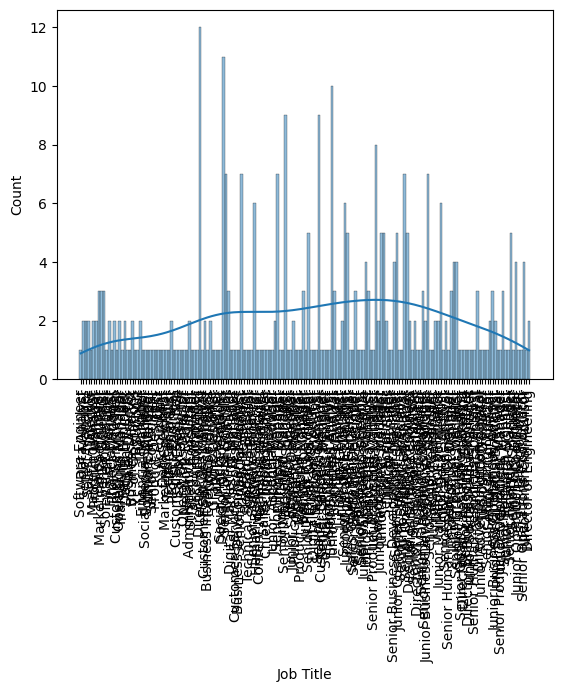

In [152]:
sns.histplot(df['Job Title'], bins=150, kde=True)
plt.xticks(rotation=90)

In [153]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [154]:
df.groupby('Job Title')['Salary'].describe()

,count,mean,std,min,25%,50%,75%,max
Job Title,,,,,,,,
Account Manager,1.0,75000.0,NaN,75000.0,75000.0,75000.0,75000.0,75000.0
Accountant,1.0,55000.0,NaN,55000.0,55000.0,55000.0,55000.0,55000.0
Administrative Assistant,2.0,50000.0,7071.067812,45000.0,47500.0,50000.0,52500.0,55000.0
Business Analyst,2.0,77500.0,3535.533906,75000.0,76250.0,77500.0,78750.0,80000.0
Business Development Manager,1.0,90000.0,NaN,90000.0,90000.0,90000.0,90000.0,90000.0
...,...,...,...,...,...,...,...,...
UX Designer,1.0,80000.0,NaN,80000.0,80000.0,80000.0,80000.0,80000.0
UX Researcher,1.0,65000.0,NaN,65000.0,65000.0,65000.0,65000.0,65000.0
VP of Finance,1.0,200000.0,NaN,200000.0,200000.0,200000.0,200000.0,200000.0


In [155]:
df['Years of Experience'].value_counts()

,count
Years of Experience,
2.0,31
3.0,30
8.0,25
9.0,22
4.0,20
16.0,18
10.0,18
7.0,18
5.0,17


# Data Cleaning & Preprocessing



In [156]:
df_encode = df.copy()

In [157]:
df_encode.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [158]:
df_encode.isna().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [159]:
df_encode.dropna(inplace=True)

In [160]:
df_encode.isna().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [161]:
df_encode.shape

(373, 6)

In [162]:
df_encode['Gender'].value_counts()

,count
Gender,
Male,194
Female,179


In [163]:
df_encode.rename(columns={'Gender': 'is_male'}, inplace=True)

In [164]:
df_encode['is_male'] = df_encode['is_male'].map({'Male': 1, 'Female': 0})

In [165]:
df_encode['is_male'].head()

,is_male
0,1
1,0
2,1
3,0
4,1


In [166]:
df_encode.head()

,Age,is_male,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,0,Master's,Data Analyst,3.0,65000.0
2,45.0,1,PhD,Senior Manager,15.0,150000.0
3,36.0,0,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,1,Master's,Director,20.0,200000.0


In [167]:
# import StandardScaler from sklearn.preprocessing for doing scaling to qualitative column
from sklearn.preprocessing import StandardScaler
# import pandas.DataFrame for data type of dataframe
from pandas import DataFrame
# import pandas.api.types.is_numeric_dtype for checking the column datatype
from pandas.api.types import is_numeric_dtype
# import Tuple from typing for storing the final return value data type hints
from typing import Tuple

scaling_return_type = Tuple[StandardScaler, float, float, float, float, float, float]

# Creating standard_scaling function which is taking the qual_col: str
def standard_scaling(
    quantitative_col: str,
    dataframe: DataFrame
    ) -> scaling_return_type | None:
    try:
      # Storing is_df_none container which store wheter dataframe is None
      is_df_none: bool = dataframe is None

      # Returning the function and showing error if dataframe is None:
      if is_df_none:
        print(f"Error the dataframe({dataframe}) cannot be None")
        return None

      # Storing wheter the dataframe instance is pd.DataFrame or not
      is_legal_df_instance: bool = isinstance(dataframe, DataFrame)

      # Returning the function and showing error if dataframe instance is not legal(pd.DataFrame)
      if not is_legal_df_instance:
        print(f"Error the dataframe({dataframe}) is not an instance of pd.DataFrame")
        return None

      # Storing wheter the qual_col exists in dataframe
      column_exists: bool = quantitative_col in dataframe

      # Storing all available qualitative columns in a list
      available_quantitative_cols: list = dataframe.select_dtypes(include='number').columns.tolist()

      # Storing container which shows available_quantitative_cols
      show_quantitative_cols: str = f"Available Quantitative Columns: {available_quantitative_cols}"

      # Showing error if column not exists
      if not column_exists:
        print(f"Error: the column '{quantitative_col}' does not exist in the dataframe!")
        print(show_quantitative_cols)
        return None

      # Storing wheter the dataframe dtype is not qualitative
      is_quantitative_col: bool = is_numeric_dtype(dataframe[quantitative_col])

      # Returning the function and showing error if data type is not numeric
      if not is_quantitative_col:
        print(f"Error: the column '{quantitative_col}' is not numeric!")
        print(show_quantitative_cols)
        return None

      # Creating scaler object container which is calling StandardScaler class
      scaler: StandardScaler= StandardScaler()

      # Performing standard scaling
      dataframe[quantitative_col] = scaler.fit_transform(
          dataframe[[quantitative_col]]
      ).ravel()

      # Creating container which we need to show for results
      scaled_min: float = dataframe[quantitative_col].min()
      scaled_max: float = dataframe[quantitative_col].max()
      scaled_mean: float = dataframe[quantitative_col].mean()
      scaled_mode: float = dataframe[quantitative_col].mode()[0]
      scaled_median: float = dataframe[quantitative_col].median()
      scaled_std: float = dataframe[quantitative_col].std()


      # Showing actual data strings:
      summary_stater = f"'Overview of 'Standard Scaling' on your DataFrame's column({quantitative_col})'"
      show_scaled_min: str = f"Scalled Min: {scaled_min}"
      show_scaled_max: str = f"Scalled Max: {scaled_max}"
      show_scaled_mean: str = f"Scalled Mean: {scaled_mean}"
      show_scaled_mode: str = f"Scalled Mode: {scaled_mode}"
      show_scaled_median: str = f"Scalled Median: {scaled_median}"
      show_scaled_std: str = f"Scalled Std: {scaled_std}"

      # Showing results
      print(f"\n{summary_stater}\n")
      print(f"\n{show_scaled_min}")
      print(show_scaled_max)
      print(show_scaled_mean)
      print(show_scaled_mode)
      print(show_scaled_median)
      print(f"{show_scaled_std}\n")

      # Returning Data in Tuple
      return (scaler, scaled_min, scaled_max, scaled_mean, scaled_mode, scaled_median, scaled_std)

    # Specifically for handling TypeError
    except TypeError as err:
      print(f"Type Error while performing standard_scaling occurs due to: {err}")
      return None

    # Specifically for handling ValueError
    except ValueError as err:
      print(f"Value Error while performing standard_scaling occurs due to: {err}")
      return None

    # Specifically for handling KeyError
    except KeyError as err:
      print(f"Key Error while performing standard_scaling occurs due to: {err}")
      return None

    # General Exception handling
    except Exception as err:
      # Showing eror:
      print(f"Error while performing standard_scaling occurs due to: {err}")
      return None

In [168]:
standard_scaling('Age', df_encode)


'Overview of 'Standard Scaling' on your DataFrame's column(Age)'


Scalled Min: -2.0442595309667233
Scalled Max: 2.205278672919145
Scalled Mean: -3.28602203535167e-16
Scalled Mode: -0.6277467963381004
Scalled Median: -0.2027929759495136
Scalled Std: 1.001343183949944



(StandardScaler(),
 -2.0442595309667233,
 2.205278672919145,
 np.float64(-3.28602203535167e-16),
 np.float64(-0.6277467963381004),
 -0.2027929759495136,
 1.001343183949944)

In [169]:
standard_scaling('Years of Experience', df_encode)


'Overview of 'Standard Scaling' on your DataFrame's column(Years of Experience)'


Scalled Min: -1.5318428273094074
Scalled Max: 2.285993432121362
Scalled Mean: 2.0239990797455938e-17
Scalled Mode: -1.226415926554946
Scalled Median: -0.15742177391433038
Scalled Std: 1.0013431839499436



(StandardScaler(),
 -1.5318428273094074,
 2.285993432121362,
 np.float64(2.0239990797455938e-17),
 np.float64(-1.226415926554946),
 -0.15742177391433038,
 1.0013431839499436)

In [170]:
df_encode.head()

,Age,is_male,Education Level,Job Title,Years of Experience,Salary
0,-0.769398,1,Bachelor's,Software Engineer,-0.768276,90000.0
1,-1.336003,0,Master's,Data Analyst,-1.073702,65000.0
2,1.072068,1,PhD,Senior Manager,0.758859,150000.0
3,-0.202793,0,Bachelor's,Sales Associate,-0.462849,60000.0
4,2.063627,1,Master's,Director,1.522426,200000.0


In [171]:
df_encode['Education Level'].value_counts()

,count
Education Level,
Bachelor's,224
Master's,98
PhD,51


# Feature Engineering & Extraction

In [172]:
df_encode = pd.get_dummies(
    df_encode,
    columns=['Education Level'],
    prefix='education_level',
    drop_first=True
)

In [173]:
df_encode.head()

,Age,is_male,Job Title,Years of Experience,Salary,education_level_Master's,education_level_PhD
0,-0.769398,1,Software Engineer,-0.768276,90000.0,False,False
1,-1.336003,0,Data Analyst,-1.073702,65000.0,True,False
2,1.072068,1,Senior Manager,0.758859,150000.0,False,True
3,-0.202793,0,Sales Associate,-0.462849,60000.0,False,False
4,2.063627,1,Director,1.522426,200000.0,True,False


In [174]:
df_encode["education_level_Master's"] = df_encode["education_level_Master's"].astype(int)

In [175]:
df_encode["education_level_PhD"] = df_encode["education_level_PhD"].astype(int)

In [176]:
df_encode.head()

,Age,is_male,Job Title,Years of Experience,Salary,education_level_Master's,education_level_PhD
0,-0.769398,1,Software Engineer,-0.768276,90000.0,0,0
1,-1.336003,0,Data Analyst,-1.073702,65000.0,1,0
2,1.072068,1,Senior Manager,0.758859,150000.0,0,1
3,-0.202793,0,Sales Associate,-0.462849,60000.0,0,0
4,2.063627,1,Director,1.522426,200000.0,1,0


In [177]:
df_encode['Salary'].min()

350.0

In [178]:
min_salary = 20000   # $20,000 minimum (absolute floor)
max_salary = 500000  # $500,000 maximum (absolute ceiling)

# Apply filter
df_encode = df_encode[(df_encode['Salary'] >= min_salary) & (df_encode['Salary'] <= max_salary)]

In [179]:
df_encode.shape

(372, 7)

In [183]:
from pandas import DataFrame
from typing import Tuple

# Define return type
job_level_return_type = Tuple[DataFrame, dict, dict, float, float, float, float]

def categorize_job_by_salary(
    dataframe: DataFrame
) -> job_level_return_type | None:
    """
    Categorize job titles into 4 levels based on median salary.

    This function:
    1. Calculates median salary for each job title
    2. Finds quartiles (Q1, Q2, Q3)
    3. Assigns each title to a level (1-4)
    4. Adds Job_Level_Encoded, Job_Level_Label, Job_Median_Salary columns

    Parameters:
    -----------
    dataframe : pd.DataFrame
        DataFrame with 'Job Title' and 'Salary' columns

    Returns:
    --------
    tuple | None:
        (dataframe, level_mapping, label_mapping, q1, q2, q3)
        Returns None if validation fails
    """
    try:
        # VALIDATION

        is_df_none = dataframe is None
        if is_df_none:
            print(f"Error: dataframe({dataframe}) cannot be None")
            return None

        is_legal_df_instance = isinstance(dataframe, DataFrame)
        if not is_legal_df_instance:
            print(f"Error: dataframe is not an instance of pd.DataFrame")
            return None

        # Check if required columns exist
        required_cols = ['Job Title', 'Salary']
        missing_cols = [col for col in required_cols if col not in dataframe.columns]
        if missing_cols:
            print(f"Error: Missing columns: {missing_cols}")
            print(f"Available columns: {dataframe.columns.tolist()}")
            return None

        # Check if Salary is numeric
        from pandas.api.types import is_numeric_dtype
        if not is_numeric_dtype(dataframe['Salary']):
            print("Error: 'Salary' column must be numeric")
            return None

        # Check for empty data
        if len(dataframe) == 0:
            print("Error: Dataframe is empty")
            return None

        # CATEGORIZATION

        print(" Categorizing job titles by median salary...")

        # Step 1: Calculate median salary per job title
        title_median_salary = dataframe.groupby('Job Title')['Salary'].median().sort_values()
        print(f"   Total unique job titles: {len(title_median_salary)}")
        print(f"   Salary range: ${title_median_salary.min():,.0f} - ${title_median_salary.max():,.0f}")

        # Step 2: Get quartiles
        q1 = title_median_salary.quantile(0.25)
        q2 = title_median_salary.quantile(0.50)
        q3 = title_median_salary.quantile(0.75)

        print(f"\nSalary Quartiles:")
        print(f"   Q1 (25th percentile): ${q1:,.0f}")
        print(f"   Q2 (50th percentile): ${q2:,.0f}")
        print(f"   Q3 (75th percentile): ${q3:,.0f}")

        # Step 3: Define mapping functions
        def get_job_level(title):
            median = title_median_salary[title]
            if median >= q3:
                return 4  # Executive/High
            elif median >= q2:
                return 3  # Senior/Mid-High
            elif median >= q1:
                return 2  # Mid Level
            else:
                return 1  # Junior/Low

        # Step 4: Apply mapping
        print("\nAssigning job levels...")
        dataframe['Job_Level_Encoded'] = dataframe['Job Title'].apply(get_job_level)

        # Step 5: Create readable labels
        job_level_labels = {
            4: 'Executive/High',
            3: 'Senior/Mid-High',
            2: 'Mid Level',
            1: 'Junior/Low'
        }
        dataframe['Job_Level_Label'] = dataframe['Job_Level_Encoded'].map(job_level_labels)

        # Step 6: Store median salary for reference
        dataframe['Job_Median_Salary'] = dataframe['Job Title'].map(title_median_salary)

        # Step 7: Store mappings for return
        level_mapping = {title: get_job_level(title) for title in title_median_salary.index}
        label_mapping = job_level_labels

        # SUMMARY

        print("\n Job Title Categorization Complete!")
        print(f"\nJob Level Distribution:")
        print(dataframe['Job_Level_Label'].value_counts().sort_index())

        print(f"\nAverage Salary by Level:")
        print(dataframe.groupby('Job_Level_Label')['Salary'].agg(['count', 'mean', 'min', 'max']).round(0))

        print(f"\nSample Job Titles by Level:")
        for level in [4, 3, 2, 1]:
            label = job_level_labels[level]
            sample_titles = dataframe[dataframe['Job_Level_Encoded'] == level]['Job Title'].head(3).tolist()
            print(f"   {label}: {sample_titles}")

        # Return everything
        return (dataframe, level_mapping, label_mapping, q1, q2, q3)

    except KeyError as err:
        print(f"Key Error while categorizing job titles: {err}")
        return None

    except ValueError as err:
        print(f"Value Error while categorizing job titles: {err}")
        return None

    except Exception as err:
        print(f"Error while categorizing job titles: {err}")
        return None

In [184]:
categorize_job_by_salary(df_encode)

 Categorizing job titles by median salary...
   Total unique job titles: 174
   Salary range: $30,000 - $250,000

Salary Quartiles:
   Q1 (25th percentile): $50,000
   Q2 (50th percentile): $92,500
   Q3 (75th percentile): $130,000

Assigning job levels...

 Job Title Categorization Complete!

Job Level Distribution:
Job_Level_Label
Executive/High     112
Junior/Low          64
Mid Level          102
Senior/Mid-High     94
Name: count, dtype: int64

Average Salary by Level:
                 count      mean      min       max
Job_Level_Label                                    
Executive/High     112  158393.0  95000.0  250000.0
Junior/Low          64   43594.0  30000.0   70000.0
Mid Level          102   66373.0  35000.0  120000.0
Senior/Mid-High     94  108670.0  80000.0  150000.0

Sample Job Titles by Level:
   Executive/High: ['Senior Manager', 'Director', 'Operations Manager']
   Senior/Mid-High: ['Product Manager', 'Sales Manager', 'Senior Scientist']
   Mid Level: ['Software Engine

(          Age  is_male                      Job Title  Years of Experience  \
 0   -0.769398        1              Software Engineer            -0.768276   
 1   -1.336003        0                   Data Analyst            -1.073702   
 2    1.072068        1                 Senior Manager             0.758859   
 3   -0.202793        0                Sales Associate            -0.462849   
 4    2.063627        1                       Director             1.522426   
 ..        ...      ...                            ...                  ...   
 370 -0.344444        0       Senior Marketing Analyst            -0.310135   
 371  0.788766        1         Director of Operations             1.369713   
 372 -1.194352        0         Junior Project Manager            -1.226416   
 373 -0.486096        1  Senior Operations Coordinator            -0.462849   
 374  0.930417        0        Senior Business Analyst             0.758859   
 
        Salary  education_level_Master's  educatio

In [185]:
df_encode.head()

,Age,is_male,Job Title,Years of Experience,Salary,education_level_Master's,education_level_PhD,Job_Level_Encoded,Job_Level_Label,Job_Median_Salary
0,-0.769398,1,Software Engineer,-0.768276,90000.0,0,0,2,Mid Level,90000.0
1,-1.336003,0,Data Analyst,-1.073702,65000.0,1,0,2,Mid Level,72500.0
2,1.072068,1,Senior Manager,0.758859,150000.0,0,1,4,Executive/High,160000.0
3,-0.202793,0,Sales Associate,-0.462849,60000.0,0,0,2,Mid Level,50000.0
4,2.063627,1,Director,1.522426,200000.0,1,0,4,Executive/High,200000.0


In [186]:
df_encode.drop(columns=['Job Title'], inplace=True)

In [187]:
df_encode.head()

,Age,is_male,Years of Experience,Salary,education_level_Master's,education_level_PhD,Job_Level_Encoded,Job_Level_Label,Job_Median_Salary
0,-0.769398,1,-0.768276,90000.0,0,0,2,Mid Level,90000.0
1,-1.336003,0,-1.073702,65000.0,1,0,2,Mid Level,72500.0
2,1.072068,1,0.758859,150000.0,0,1,4,Executive/High,160000.0
3,-0.202793,0,-0.462849,60000.0,0,0,2,Mid Level,50000.0
4,2.063627,1,1.522426,200000.0,1,0,4,Executive/High,200000.0


In [188]:
job_level_dummies = pd.get_dummies(
    df_encode['Job_Level_Encoded'],
    prefix='job_level',
    dtype=int
)

# Add to dataframe
df_encode = pd.concat([df_encode, job_level_dummies], axis=1)

# Check new columns
print("Job Level Dummies Created!")
print(f"New columns: {job_level_dummies.columns.tolist()}")
print("\nSample:")
print(df_encode[['Job_Level_Encoded', 'job_level_1', 'job_level_2', 'job_level_3', 'job_level_4']].head())


Job Level Dummies Created!
New columns: ['job_level_1', 'job_level_2', 'job_level_3', 'job_level_4']

Sample:
   Job_Level_Encoded  job_level_1  job_level_2  job_level_3  job_level_4
0                  2            0            1            0            0
1                  2            0            1            0            0
2                  4            0            0            0            1
3                  2            0            1            0            0
4                  4            0            0            0            1


In [189]:
df_encode.head()

,Age,is_male,Years of Experience,Salary,education_level_Master's,education_level_PhD,Job_Level_Encoded,Job_Level_Label,Job_Median_Salary,job_level_1,job_level_2,job_level_3,job_level_4
0,-0.769398,1,-0.768276,90000.0,0,0,2,Mid Level,90000.0,0,1,0,0
1,-1.336003,0,-1.073702,65000.0,1,0,2,Mid Level,72500.0,0,1,0,0
2,1.072068,1,0.758859,150000.0,0,1,4,Executive/High,160000.0,0,0,0,1
3,-0.202793,0,-0.462849,60000.0,0,0,2,Mid Level,50000.0,0,1,0,0
4,2.063627,1,1.522426,200000.0,1,0,4,Executive/High,200000.0,0,0,0,1


In [190]:
rename_cols = {
    'Age': 'age',
    'Years of Experience': 'years_of_experience',
    'Salary': 'salary',
}

df_encode.rename(columns=rename_cols, inplace=True)

In [192]:
df_encode.drop(columns=['Job_Level_Encoded', 'Job_Level_Label', 'Job_Median_Salary'], inplace=True)

In [193]:
df_encode.head()

,age,is_male,years_of_experience,salary,education_level_Master's,education_level_PhD,job_level_1,job_level_2,job_level_3,job_level_4
0,-0.769398,1,-0.768276,90000.0,0,0,0,1,0,0
1,-1.336003,0,-1.073702,65000.0,1,0,0,1,0,0
2,1.072068,1,0.758859,150000.0,0,1,0,0,0,1
3,-0.202793,0,-0.462849,60000.0,0,0,0,1,0,0
4,2.063627,1,1.522426,200000.0,1,0,0,0,0,1


In [194]:
final_df = df_encode.copy()

In [199]:
X = final_df.drop(columns=['salary'])
Y = final_df['salary']

# Creating Model & Evaluating Model

In [200]:
# Importing linear regression model for from scikit learn
from sklearn.linear_model import LinearRegression

In [222]:
# importing test split test
from sklearn.model_selection import train_test_split

# Performing train test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [223]:
X_train.head()

,age,is_male,years_of_experience,education_level_Master's,education_level_PhD,job_level_1,job_level_2,job_level_3,job_level_4
193,-0.486096,1,-0.462849,0,0,0,0,1,0
75,-0.061142,1,-0.004708,0,0,0,0,1,0
84,-1.194352,0,-1.226416,0,0,1,0,0,0
363,-0.627747,1,-0.768276,0,0,1,0,0,0
16,-0.627747,0,-0.462849,1,0,0,1,0,0


In [224]:
Y_train.head()

,salary
193,95000.0
75,95000.0
84,40000.0
363,70000.0
16,90000.0


In [225]:
X_test.head()

,age,is_male,years_of_experience,education_level_Master's,education_level_PhD,job_level_1,job_level_2,job_level_3,job_level_4
330,-0.911049,0,-1.073702,0,0,1,0,0,0
33,0.222161,0,-0.004708,0,0,0,1,0,0
15,0.930417,1,0.911572,0,0,0,0,0,1
317,-0.202793,1,-0.310135,0,0,0,0,1,0
57,0.788766,1,1.064286,0,1,0,0,1,0


In [226]:
Y_test.head()

,salary
330,50000.0
33,65000.0
15,125000.0
317,95000.0
57,140000.0


In [227]:

# Creating model
model: LinearRegression = LinearRegression()

# Fitting data inside it
model.fit(X_train, Y_train)

LinearRegression()

In [228]:
# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# creating Y_pred for prediction
Y_pred: np.array = model.predict(X_test)

In [229]:
Y_pred

array([ 46461.42945432,  81016.71908813, 140872.05373856,  95723.07484422,
       143121.21103794, 155555.34067294, 157309.05234081, 110212.76834252,
       125176.17250072, 108697.73817638, 145165.1346525 , 159776.6106084 ,
        37576.51992272,  96665.86926839, 124084.77698762, 106493.57322416,
        62684.39796026,  54387.78468487, 137825.26949783, 108327.17949418,
       122331.06531976, 114946.20781795, 162756.33841596,  59274.04526849,
        97355.00405448,  49816.89999493, 167480.0442141 ,  48503.54688856,
       120983.26672246, 156304.54166104,  37947.07860493, 105906.35228416,
        55122.57521232, 137825.26949783, 178822.778336  ,  21399.50779552,
       173146.54443641,  54179.78078815, 152717.22372315,  53652.69352005,
        42680.51808035, 165189.45119263, 166385.90525488, 170495.12641002,
        43252.75382232, 138768.063922  , 117597.62584434,  54859.18189695,
        51341.66383835,  37004.28418076,  41312.28282282,  90046.84094463,
        61741.60353609, 1

In [232]:
# Creating evualtion containers
mae: float = mean_absolute_error(Y_test, Y_pred)
mse: float = mean_squared_error(Y_test, Y_pred)
rmse: float = np.sqrt(mse)
r2: float = r2_score(Y_test, Y_pred)
n: int = X_test.shape[0]
p: int = X_test.shape[1]
adjusted_r2: float = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

In [233]:
# ============================================
# MODEL SUMMARY FUNCTION
# ============================================

def showing_model_summary():
    """
    Display comprehensive model summary using existing variables.
    Just call showing_model_summary() to see results!
    """
    try:
        # 1. PRINT PERFORMANCE METRICS

        print("=" * 70)
        print("LINEAR REGRESSION MODEL SUMMARY")
        print("=" * 70)

        print("\nPERFORMANCE METRICS:")
        print("-" * 70)
        print(f"   R² Score (Test):     {r2:.4f}")
        print(f"   Adjusted R²:         {adjusted_r2:.4f}")
        print(f"   MAE:                 ${mae:,.2f}")
        print(f"   RMSE:                ${rmse:,.2f}")
        print(f"   MSE:                 ${mse:,.2f}")

        # TRAINING R² (Overfitting Check)

        y_train_pred = model.predict(X_train)
        r2_train = r2_score(Y_train, y_train_pred)

        print(f"\n   R² Score (Train):    {r2_train:.4f}")

        # Overfitting check
        r2_diff = r2_train - r2
        print("\OVERFITTING CHECK:")
        print("-" * 70)
        if r2_diff < 0.05:
            print(f"   No overfitting! (R² diff: {r2_diff:.4f})")
        elif r2_diff < 0.10:
            print(f"   Slight overfitting. (R² diff: {r2_diff:.4f})")
        else:
            print(f"   Significant overfitting! (R² diff: {r2_diff:.4f})")

        # DATA INFORMATION

        print("\nDATA INFORMATION:")
        print("-" * 70)
        print(f"   Training samples:    {X_train.shape[0]}")
        print(f"   Test samples:        {X_test.shape[0]}")
        print(f"   Total features:      {X_test.shape[1]}")
        print(f"   Total samples:       {X_train.shape[0] + X_test.shape[0]}")

        # MODEL EQUATION

        print("\nMODEL EQUATION:")
        print("-" * 70)

        feature_names = X_train.columns.tolist()
        intercept = model.intercept_
        coefficients = model.coef_

        equation = f"Salary = ${intercept:,.2f}"
        for i, (name, coef) in enumerate(zip(feature_names, coefficients)):
            if coef >= 0:
                equation += f" + (${coef:,.2f} × {name})"
            else:
                equation += f" - (${abs(coef):,.2f} × {name})"

        print(f"   {equation}")

        # FEATURE IMPORTANCE

        print("\nFEATURE IMPORTANCE:")
        print("-" * 70)

        feature_importance = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': coefficients,
            'Abs_Coefficient': abs(coefficients)
        }).sort_values('Abs_Coefficient', ascending=False)

        for idx, row in feature_importance.iterrows():
            feature = row['Feature']
            coef = row['Coefficient']
            direction = "Increases" if coef > 0 else "Decreases"
            print(f"   {feature:30s} → {direction} salary by ${abs(coef):.2f} per unit")

        # 6. INTERPRETATION

        print("\nMODEL INTERPRETATION:")
        print("-" * 70)

        if r2 > 0.8:
            print("Excellent model! Great predictive power.")
        elif r2 > 0.6:
            print(" Good model! Solid predictive power.")
        elif r2 > 0.4:
            print("Moderate model. Consider adding more features.")
        else:
            print(" Poor model. Consider feature engineering or a different algorithm.")

        best_feature = feature_importance.iloc[0]['Feature']
        print(f"   • Most important feature: {best_feature}")

        # SAMPLE PREDICTIONS

        print("\SAMPLE PREDICTIONS (First 5):")
        print("-" * 70)

        sample_comparison = pd.DataFrame({
            'Actual': Y_test.values[:5],
            'Predicted': Y_pred[:5],
            'Error': Y_test.values[:5] - Y_pred[:5]
        })
        print(sample_comparison.round(2).to_string(index=False))

        print("\n" + "=" * 70)
        print("Model Summary Complete!")
        print("=" * 70)

        return True

    except Exception as err:
        print(f"Error while showing model summary: {err}")
        return None

In [234]:
showing_model_summary()

LINEAR REGRESSION MODEL SUMMARY

PERFORMANCE METRICS:
----------------------------------------------------------------------
   R² Score (Test):     0.9284
   Adjusted R²:         0.9185
   MAE:                 $8,454.09
   RMSE:                $13,499.69
   MSE:                 $182,241,730.87

   R² Score (Train):    0.9249
\OVERFITTING CHECK:
----------------------------------------------------------------------
   No overfitting! (R² diff: -0.0035)

DATA INFORMATION:
----------------------------------------------------------------------
   Training samples:    297
   Test samples:        75
   Total features:      9
   Total samples:       372

MODEL EQUATION:
----------------------------------------------------------------------
   Salary = $88,436.22 + ($20,035.94 × age) + ($6,248.47 × is_male) + ($6,173.62 × years_of_experience) + ($15,442.22 × education_level_Master's) + ($19,046.17 × education_level_PhD) - ($17,092.43 × job_level_1) - ($11,841.64 × job_level_2) + ($7,016.19 × 

True

In [235]:
# PREDICT SALARY FOR A SINGLE PERSON

def predict_salary(
    age: float,
    is_male: int,
    years_experience: float,
    education_masters: int,
    education_phd: int,
    job_level_1: int,
    job_level_2: int,
    job_level_3: int,
    job_level_4: int
) -> float:
    """
    Predict salary based on input features.

    Parameters:
    -----------
    age : float (scaled)
    is_male : int (0 or 1)
    years_experience : float (scaled)
    education_masters : int (0 or 1)
    education_phd : int (0 or 1)
    job_level_1 : int (0 or 1)  # Junior
    job_level_2 : int (0 or 1)  # Mid Level
    job_level_3 : int (0 or 1)  # Senior
    job_level_4 : int (0 or 1)  # Executive

    Returns:
    --------
    float: Predicted salary in dollars
    """

    # Create input array
    input_data = [[
        age,
        is_male,
        years_experience,
        education_masters,
        education_phd,
        job_level_1,
        job_level_2,
        job_level_3,
        job_level_4
    ]]

    # Make prediction
    prediction = model.predict(input_data)[0]

    return prediction

# EXAMPLE USAGE:

# Example 1: Junior Software Engineer (Female, 25 years old)
salary_1 = predict_salary(
    age=-0.77,              # Scaled age (25 years old)
    is_male=0,              # Female
    years_experience=-0.77, # 2 years experience
    education_masters=0,    # No Master's
    education_phd=0,        # No PhD
    job_level_1=1,          # Junior
    job_level_2=0,
    job_level_3=0,
    job_level_4=0
)
print(f"Junior Female (25 yrs, 2 yrs exp): ${salary_1:,.2f}")

# Example 2: Senior Manager (Male, 40 years old)
salary_2 = predict_salary(
    age=0.45,               # Scaled age (40 years old)
    is_male=1,              # Male
    years_experience=0.45,  # 8 years experience
    education_masters=1,    # Has Master's
    education_phd=0,        # No PhD
    job_level_1=0,
    job_level_2=0,
    job_level_3=1,          # Senior
    job_level_4=0
)
print(f"Senior Manager (40 yrs, 8 yrs exp): ${salary_2:,.2f}")

# Example 3: Executive (Female, 50 years old)
salary_3 = predict_salary(
    age=1.32,               # Scaled age (50 years old)
    is_male=0,              # Female
    years_experience=1.32,  # 20 years experience
    education_masters=1,    # Has Master's
    education_phd=1,        # Has PhD
    job_level_1=0,
    job_level_2=0,
    job_level_3=0,
    job_level_4=1           # Executive
)
print(f"Executive (50 yrs, 20 yrs exp): ${salary_3:,.2f}")

Junior Female (25 yrs, 2 yrs exp): $51,162.43
Senior Manager (40 yrs, 8 yrs exp): $128,937.40
Executive (50 yrs, 20 yrs exp): $179,439.11


In [236]:
# QUICK DOWNLOAD (Most Common Files)

from google.colab import files
import joblib

# Save and download model
joblib.dump(model, 'salary_model.pkl')
files.download('salary_model.pkl')

# Save and download final data
final_df.to_csv('final_cleaned_data.csv', index=False)
files.download('final_cleaned_data.csv')

print("Model and data downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model and data downloaded!


In [ ]:
joblib.dump(model, 'salary_model.pkl')
joblib.dump(scaler, 'scaler.pkl')  # ← Save this